# TP Module 3 — Autoencoders & Débruitage d'images médicales (DermaMNIST)

**Formation avancée en Deep Learning avec PyTorch — Computer Vision & Séries temporelles**

*Bassem Ben Hamed — ENETCOM, Université de Sfax*

---

## Objectifs du TP

1. Comprendre l'architecture **encodeur–décodeur** et le principe du **goulot d'étranglement** (*bottleneck*) qui force l'apprentissage d'une représentation compressée
2. Formuler et minimiser une **loss de reconstruction** (MSE / BCE) — apprentissage **non supervisé** (l'image est sa propre cible)
3. Comparer un **AE dense** (`nn.Linear`) et un **ConvAE** (`nn.Conv2d` / `nn.ConvTranspose2d`) ; comprendre le piège des **artefacts en damier** (*checkerboard*) et l'alternative `Upsample + Conv`
4. Implémenter un **Denoising Autoencoder (DAE)** : bruiter l'entrée (`torch.randn_like`) et reconstruire l'image **propre**
5. Ajouter des **skip connections** (style **U-Net**) pour préserver les détails fins, et mesurer le gain en **PSNR**
6. Exploiter l'**espace latent** : visualisation **UMAP**, et **détection d'anomalies** non supervisée par seuil sur l'erreur de reconstruction

## Pré-requis

- Modules 1 et 2 (PyTorch, MLP, CNN, transfer learning)
- `torch`, `torchvision`, `medmnist`, `matplotlib`, `numpy`, `scikit-learn` ; **optionnel** : `umap-learn`

## Dataset

On poursuit le **fil rouge médical** sur **DermaMNIST** (collection [MedMNIST](https://medmnist.com/), dérivé de HAM10000) — images dermatoscopiques **RGB** de lésions cutanées, **7 classes**, fortement **déséquilibré** (la classe *melanocytic nevi* — `nv` — domine). En apprentissage non supervisé, les **labels ne servent pas à l'entraînement** : ils n'interviennent que pour *colorer* la projection latente et pour la détection d'anomalies. Téléchargement automatique via `medmnist` dans `./data/`.


## Partie I — Théorie des Autoencoders

### I.1 Principe : encodeur, décodeur, bottleneck

Un **autoencoder** (AE) apprend à se reconstruire lui-même. Il enchaîne deux réseaux :

- un **encodeur** $E_\phi : \mathbb{R}^{D} \to \mathbb{R}^{d}$ qui projette l'entrée $\mathbf{x}$ vers un **code latent** $\mathbf{z} = E_\phi(\mathbf{x})$ ;
- un **décodeur** $D_\theta : \mathbb{R}^{d} \to \mathbb{R}^{D}$ qui reconstruit $\hat{\mathbf{x}} = D_\theta(\mathbf{z})$.

La dimension latente $d \ll D$ constitue un **goulot d'étranglement** (*bottleneck*). C'est cette contrainte qui rend la tâche non triviale : le réseau **ne peut pas** simplement copier l'entrée, il doit en apprendre une **représentation compressée** qui retient l'essentiel (structure, texture) et jette le superflu.

$$
\mathbf{x} \;\xrightarrow{\;E_\phi\;}\; \mathbf{z}\in\mathbb{R}^{d} \;\xrightarrow{\;D_\theta\;}\; \hat{\mathbf{x}} .
$$

C'est de l'apprentissage **auto-supervisé** : la cible est l'entrée elle-même, **aucun label n'est requis**.


### I.2 Loss de reconstruction

On minimise l'écart entre l'entrée et sa reconstruction. Pour des pixels normalisés dans $[0,1]$, deux choix usuels :

$$
\mathcal{L}_{\text{MSE}}(\theta,\phi) = \frac{1}{N}\sum_{i=1}^{N}\bigl\| \mathbf{x}_i - \hat{\mathbf{x}}_i \bigr\|_2^2,
\qquad
\mathcal{L}_{\text{BCE}} = -\frac{1}{N}\sum_{i}\sum_{p} \Bigl[x_{i,p}\log\hat{x}_{i,p} + (1-x_{i,p})\log(1-\hat{x}_{i,p})\Bigr].
$$

- **MSE** suppose implicitement un décodeur gaussien ; c'est le choix par défaut (plan de formation).
- **BCE** convient quand les pixels sont vus comme des probabilités $[0,1]$ ; elle pénalise plus fortement les erreurs proches de 0 ou 1 (contours).

Dans les deux cas la dernière couche du décodeur passe par une **sigmoïde** pour garantir $\hat{\mathbf{x}} \in [0,1]$.


### I.3 Décodeur convolutif : `ConvTranspose2d` vs `Upsample + Conv2d`

L'encodeur **réduit** la résolution (`stride=2`) ; le décodeur doit la **restaurer**. Deux mécanismes d'*upsampling appris* :

**1. Convolution transposée** `nn.ConvTranspose2d`. La taille de sortie d'une couche transposée :
$$
H_{\text{out}} = (H_{\text{in}}-1)\cdot s - 2p + k + p_{\text{out}}.
$$
Pour **doubler** la résolution on prend typiquement $k=4,\, s=2,\, p=1$ (alors $H_{\text{out}} = 2H_{\text{in}}$).

⚠️ **Artefacts en damier** (*checkerboard*) : quand $k$ n'est pas divisible par $s$ (cas $k=3, s=2$), les noyaux se chevauchent de façon inégale et produisent une grille visible. Remèdes : choisir $k$ multiple de $s$ ($k=4, s=2$), **ou** :

**2. `Upsample + Conv2d`** — interpolation déterministe (`nearest` / `bilinear`) qui **double** la taille, suivie d'une `Conv2d(stride=1)` qui *affine*. Pas de chevauchement inégal $\Rightarrow$ **pas de damier**. C'est l'approche recommandée pour les images lisses (IRM, dermatoscopie).


### I.4 Denoising Autoencoder (DAE)

Un AE classique risque d'apprendre l'**identité** si le bottleneck est trop large. Le **Denoising AE** (Vincent et al., 2008) brise ce risque : on **corrompt l'entrée** par un bruit $\boldsymbol{\eta}$ et on demande de reconstruire l'image **propre** :

$$
\tilde{\mathbf{x}} = \mathbf{x} + \boldsymbol{\eta},\quad \boldsymbol{\eta}\sim\mathcal{N}(\mathbf{0},\sigma^2\mathbf{I}),
\qquad
\mathcal{L} = \bigl\| \mathbf{x} - D_\theta\bigl(E_\phi(\tilde{\mathbf{x}})\bigr) \bigr\|_2^2 .
$$

La cible reste $\mathbf{x}$ (le **propre**), pas $\tilde{\mathbf{x}}$. Pour réussir, le réseau doit apprendre la **structure** des images naturelles (corrélations spatiales) afin de distinguer signal et bruit. Application directe : **débruitage** d'imagerie médicale (IRM, CT — bruit gaussien, bruit de Poisson, artefacts).

En PyTorch : `noisy = (x + sigma * torch.randn_like(x)).clamp(0, 1)`.


### I.5 Skip connections — l'architecture U-Net

Le bottleneck d'un AC profond **détruit les hautes fréquences** (contours, fines textures) : la reconstruction est *floue*. Le **U-Net** (Ronneberger et al., 2015) ajoute des **connexions de saut** (*skip connections*) qui relient chaque étage de l'encodeur à l'étage symétrique du décodeur :

$$
\mathbf{h}^{\text{dec}}_{\ell} = f\bigl(\;[\,\text{up}(\mathbf{h}^{\text{dec}}_{\ell+1})\;\Vert\;\mathbf{h}^{\text{enc}}_{\ell}\,]\;\bigr),
$$

où $\Vert$ est la **concaténation** sur les canaux. Le décodeur dispose ainsi à la fois du **contexte global** (venu du bottleneck) et des **détails fins** (venus directement de l'encodeur). C'est l'architecture de référence pour le **débruitage** et la **segmentation** ; on la retrouvera au cœur des **modèles de diffusion** (TP 09).


### I.6 Espace latent : exploration & détection d'anomalies

Le code $\mathbf{z}$ est une **représentation compacte** exploitable au-delà de la reconstruction :

- **Exploration / clustering** — projeter les $\mathbf{z}$ en 2D (**UMAP**, t-SNE, PCA) révèle si l'AE a organisé les images par similarité visuelle, sans aucun label.
- **Détection d'anomalies** — on entraîne l'AE **uniquement sur des données normales**. À l'inférence, le **score d'anomalie** est l'erreur de reconstruction :
$$
s(\mathbf{x}) = \bigl\| \mathbf{x} - \hat{\mathbf{x}} \bigr\|_2^2,
\qquad \text{anomalie si } s(\mathbf{x}) > \tau .
$$
L'AE n'ayant **jamais vu** d'anomalie, il la reconstruit mal $\Rightarrow$ $s$ élevé. Le seuil $\tau$ se fixe sur un **quantile élevé** (p. ex. 95–99 %) de $s$ mesuré sur des données normales de validation.

⚠️ **Limite** : un AE déterministe **ne génère pas** d'images nouvelles — son latent n'a pas de structure probabiliste (zones « vides », pas de prior pour échantillonner). C'est précisément ce que corrige le **VAE** (TP 08).


## Partie II — Préparation des données

Pour la reconstruction, on **n'utilise pas** la normalisation ImageNet : on garde les pixels dans $[0,1]$ (cohérent avec une sortie sigmoïde et une loss MSE/BCE). La cible d'entraînement est **l'image elle-même**.


In [7]:
import os
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision.transforms import v2 as T
from medmnist import DermaMNIST, INFO

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch  : {torch.__version__}")
print(f"Device   : {device}")

ROOT     = Path("./data")
CKPT_DIR = Path("./checkpoints")
ROOT.mkdir(exist_ok=True); CKPT_DIR.mkdir(exist_ok=True)

IMG_SIZE = 64                 # 64×64 — résolution native demandée à MedMNIST (fallback : upscaling depuis 28×28)
BATCH    = 128

info          = INFO["dermamnist"]
NUM_CLASSES   = len(info["label"])                                  # 7
CLASSES       = [info["label"][str(i)] for i in range(NUM_CLASSES)] # noms longs
CLASSES_SHORT = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]
print(f"Classes ({NUM_CLASSES}) :")
for i, name in enumerate(CLASSES):
    print(f"  {i} — {CLASSES_SHORT[i]:<6} {name}")

PyTorch  : 2.10.0
Device   : cpu
Classes (7) :
  0 — akiec  actinic keratoses and intraepithelial carcinoma
  1 — bcc    basal cell carcinoma
  2 — bkl    benign keratosis-like lesions
  3 — df     dermatofibroma
  4 — mel    melanoma
  5 — nv     melanocytic nevi
  6 — vasc   vascular lesions


In [8]:
def make_derma(split, transform=None, target_transform=None):
    '''Charge un split DermaMNIST en demandant size=IMG_SIZE (RGB natif),
    avec repli sur 28×28 si la version de medmnist ne connaît pas `size`.'''
    kwargs = dict(split=split, root=ROOT, download=True,
                  transform=transform, target_transform=target_transform)
    try:
        return DermaMNIST(size=IMG_SIZE, **kwargs)
    except TypeError:
        return DermaMNIST(**kwargs)            # medmnist < 3.0 : images 28×28

# L'étiquette MedMNIST est un tableau (1,) -> entier scalaire (utilisé pour la coloration latente)
# /!\ Fonction NOMMÉE (pas un lambda) : un lambda n'est pas picklable, ce qui fait
# planter DataLoader(num_workers > 0) sous macOS/Windows (méthode « spawn ») avec
# « PicklingError: Can't pickle <lambda> ».
def squeeze_target(t):
    return int(np.asarray(t).reshape(-1)[0])

# Transformation : simple passage en tenseur float32 dans [0, 1] (pas de normalisation ImageNet)
to_tensor = T.Compose([
    T.Resize(IMG_SIZE, antialias=True),
    T.CenterCrop(IMG_SIZE),
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),     # uint8 [0,255] -> float [0,1]
])

train_set = make_derma("train", transform=to_tensor, target_transform=squeeze_target)
val_set   = make_derma("val",   transform=to_tensor, target_transform=squeeze_target)
test_set  = make_derma("test",  transform=to_tensor, target_transform=squeeze_target)

print(f"Train : {len(train_set)}  |  Val : {len(val_set)}  |  Test : {len(test_set)}")
x0, y0 = train_set[0]
print(f"Tenseur image : {tuple(x0.shape)}  dtype={x0.dtype}  min={x0.min():.2f}  max={x0.max():.2f}")
print(f"Label exemple : {y0} ({CLASSES_SHORT[y0]})")

train_loader = DataLoader(train_set, batch_size=BATCH, shuffle=True,  num_workers=0, drop_last=True)
val_loader   = DataLoader(val_set,   batch_size=BATCH, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_set,  batch_size=BATCH, shuffle=False, num_workers=0)

Train : 7007  |  Val : 1003  |  Test : 2005
Tenseur image : (3, 64, 64)  dtype=torch.float32  min=0.31  max=0.84
Label exemple : 0 (akiec)


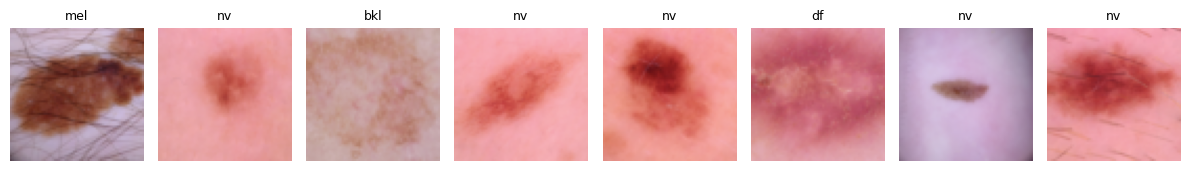

Batch : (128, 3, 64, 64)


In [9]:
# Aperçu : 8 images du train
def show_grid(imgs, titles=None, nrow=8, figsize=None, cmap=None):
    '''Affiche une grille d'images (tenseurs CHW dans [0,1]).'''
    n = len(imgs)
    ncol = nrow
    nrows = (n + ncol - 1) // ncol
    figsize = figsize or (1.5 * ncol, 1.7 * nrows)
    fig, axes = plt.subplots(nrows, ncol, figsize=figsize)
    axes = np.atleast_1d(axes).ravel()
    for i, ax in enumerate(axes):
        ax.axis("off")
        if i < n:
            img = imgs[i].detach().cpu().clamp(0, 1).permute(1, 2, 0).numpy()
            ax.imshow(img, cmap=cmap)
            if titles is not None:
                ax.set_title(titles[i], fontsize=9)
    plt.tight_layout(); plt.show()

x_batch, y_batch = next(iter(train_loader))
show_grid([x_batch[i] for i in range(8)],
          titles=[CLASSES_SHORT[int(y_batch[i])] for i in range(8)])
print(f"Batch : {tuple(x_batch.shape)}")

## Partie III — AE dense (baseline)

On commence par un autoencodeur **entièrement connecté** : on aplatit l'image ($3\times64\times64 = 12\,288$ valeurs) et on la comprime jusqu'à un latent de dimension $d=64$. C'est le **témoin** : il ignore la structure spatiale 2D et explose en paramètres — exactement les défauts qui justifieront le passage au ConvAE.


In [10]:
class DenseAE(nn.Module):
    def __init__(self, img_size=IMG_SIZE, latent_dim=64):
        super().__init__()
        self.img_size = img_size
        self.in_dim   = 3 * img_size * img_size
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(self.in_dim, 512), nn.ReLU(inplace=True),
            nn.Linear(512, 128),         nn.ReLU(inplace=True),
            nn.Linear(128, latent_dim),                         # code latent z
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128), nn.ReLU(inplace=True),
            nn.Linear(128, 512),        nn.ReLU(inplace=True),
            nn.Linear(512, self.in_dim),
            nn.Sigmoid(),                                       # pixels dans [0, 1]
        )

    def encode(self, x):
        return self.encoder(x)

    def forward(self, x):
        z   = self.encoder(x)
        out = self.decoder(z)
        return out.view(-1, 3, self.img_size, self.img_size)

def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

dense_ae = DenseAE().to(device)
with torch.no_grad():
    rec = dense_ae(x_batch.to(device))
print(f"DenseAE — paramètres : {count_params(dense_ae):,}")
print(f"Reconstruction : {tuple(rec.shape)}  (attendu {tuple(x_batch.shape)})")
print(f"Coût de la 1re couche seule : {dense_ae.in_dim * 512:,} poids — l'image n'est pas vue comme une grille 2D.")

DenseAE — paramètres : 12,744,000
Reconstruction : (128, 3, 64, 64)  (attendu (128, 3, 64, 64))
Coût de la 1re couche seule : 6,291,456 poids — l'image n'est pas vue comme une grille 2D.


## Partie IV — ConvAE (encodeur Conv / décodeur ConvTranspose)

L'encodeur empile des `Conv2d(stride=2)` qui **divisent par 2** la résolution à chaque étage :
$64 \to 32 \to 16 \to 8$, avec $3 \to 32 \to 64 \to 128$ canaux. Le décodeur **symétrise** avec des `ConvTranspose2d(k=4, s=2, p=1)` ($k$ multiple de $s$ $\Rightarrow$ pas de damier). Le code latent est ici un **tenseur spatial** $128\times8\times8$ — bien plus économe que le AE dense.


In [11]:
def enc_block(in_c, out_c):
    '''Conv stride 2 : divise la résolution par 2.'''
    return nn.Sequential(
        nn.Conv2d(in_c, out_c, kernel_size=4, stride=2, padding=1, bias=False),
        nn.BatchNorm2d(out_c),
        nn.ReLU(inplace=True),
    )

def dec_block(in_c, out_c, last=False):
    '''ConvTranspose stride 2 : double la résolution. k=4, s=2 -> pas de damier.'''
    layers = [nn.ConvTranspose2d(in_c, out_c, kernel_size=4, stride=2, padding=1,
                                 bias=last)]
    if last:
        layers.append(nn.Sigmoid())               # sortie dans [0, 1]
    else:
        layers += [nn.BatchNorm2d(out_c), nn.ReLU(inplace=True)]
    return nn.Sequential(*layers)

class ConvAE(nn.Module):
    def __init__(self, base=32):
        super().__init__()
        self.encoder = nn.Sequential(
            enc_block(3,      base),       # 64 -> 32
            enc_block(base,   base * 2),   # 32 -> 16
            enc_block(base*2, base * 4),   # 16 -> 8   (bottleneck spatial : base*4 x 8 x 8)
        )
        self.decoder = nn.Sequential(
            dec_block(base*4, base * 2),   # 8  -> 16
            dec_block(base*2, base),       # 16 -> 32
            dec_block(base,   3, last=True)# 32 -> 64
        )

    def encode(self, x):
        return self.encoder(x)             # (N, base*4, 8, 8)

    def forward(self, x):
        return self.decoder(self.encoder(x))

conv_ae = ConvAE().to(device)
with torch.no_grad():
    z   = conv_ae.encode(x_batch.to(device))
    rec = conv_ae(x_batch.to(device))
print(f"ConvAE — paramètres : {count_params(conv_ae):,}  (vs DenseAE : {count_params(dense_ae):,})")
print(f"Bottleneck latent : {tuple(z.shape)}  ->  {z[0].numel()} valeurs / image")
print(f"Reconstruction    : {tuple(rec.shape)}")

ConvAE — paramètres : 331,395  (vs DenseAE : 12,744,000)
Bottleneck latent : (128, 128, 8, 8)  ->  8192 valeurs / image
Reconstruction    : (128, 3, 64, 64)


## Partie V — Entraînement (reconstruction)

La boucle est plus simple qu'en classification : **pas de labels**, la cible est l'entrée. On suit la loss MSE sur train et validation.


In [12]:
def train_recon_epoch(model, loader, criterion, optimizer, device, noise_std=0.0):
    '''Une epoch de reconstruction. Si noise_std>0 : entrée bruitée, cible propre (DAE).'''
    model.train()
    tot_loss, tot = 0.0, 0
    for x, _ in loader:
        x = x.to(device, non_blocking=True)
        inp = x if noise_std == 0 else (x + noise_std * torch.randn_like(x)).clamp(0, 1)
        optimizer.zero_grad()
        out  = model(inp)
        loss = criterion(out, x)                 # cible = image propre
        loss.backward()
        optimizer.step()
        tot_loss += loss.item() * x.size(0); tot += x.size(0)
    return tot_loss / tot

@torch.no_grad()
def eval_recon(model, loader, criterion, device, noise_std=0.0):
    model.eval()
    tot_loss, tot = 0.0, 0
    for x, _ in loader:
        x = x.to(device, non_blocking=True)
        inp = x if noise_std == 0 else (x + noise_std * torch.randn_like(x)).clamp(0, 1)
        out  = model(inp)
        loss = criterion(out, x)
        tot_loss += loss.item() * x.size(0); tot += x.size(0)
    return tot_loss / tot

def fit(model, epochs, lr=1e-3, noise_std=0.0, tag="AE"):
    '''Entraîne un (D)AE et renvoie l'historique des loss train/val.'''
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    hist = {"train": [], "val": []}
    for ep in range(1, epochs + 1):
        t0 = time.time()
        tr = train_recon_epoch(model, train_loader, criterion, optimizer, device, noise_std)
        va = eval_recon(model, val_loader, criterion, device, noise_std)
        hist["train"].append(tr); hist["val"].append(va)
        print(f"[{tag}] epoch {ep:2d}/{epochs}  train MSE {tr:.5f}  val MSE {va:.5f}  ({time.time()-t0:.1f}s)")
    return hist

In [13]:
EPOCHS = 15
torch.manual_seed(SEED)
conv_ae = ConvAE().to(device)
hist_conv = fit(conv_ae, EPOCHS, lr=1e-3, tag="ConvAE")

[ConvAE] epoch  1/15  train MSE 0.01050  val MSE 0.00287  (13.2s)
[ConvAE] epoch  2/15  train MSE 0.00190  val MSE 0.00154  (13.2s)
[ConvAE] epoch  3/15  train MSE 0.00125  val MSE 0.00105  (12.9s)
[ConvAE] epoch  4/15  train MSE 0.00101  val MSE 0.00140  (12.8s)
[ConvAE] epoch  5/15  train MSE 0.00092  val MSE 0.00085  (13.0s)
[ConvAE] epoch  6/15  train MSE 0.00081  val MSE 0.00081  (12.8s)
[ConvAE] epoch  7/15  train MSE 0.00075  val MSE 0.00073  (12.8s)
[ConvAE] epoch  8/15  train MSE 0.00071  val MSE 0.00076  (12.8s)
[ConvAE] epoch  9/15  train MSE 0.00069  val MSE 0.00106  (12.9s)
[ConvAE] epoch 10/15  train MSE 0.00071  val MSE 0.00067  (12.9s)
[ConvAE] epoch 11/15  train MSE 0.00064  val MSE 0.00054  (12.9s)
[ConvAE] epoch 12/15  train MSE 0.00061  val MSE 0.00052  (13.1s)
[ConvAE] epoch 13/15  train MSE 0.00054  val MSE 0.00050  (12.9s)
[ConvAE] epoch 14/15  train MSE 0.00060  val MSE 0.00066  (12.9s)
[ConvAE] epoch 15/15  train MSE 0.00060  val MSE 0.00091  (12.9s)


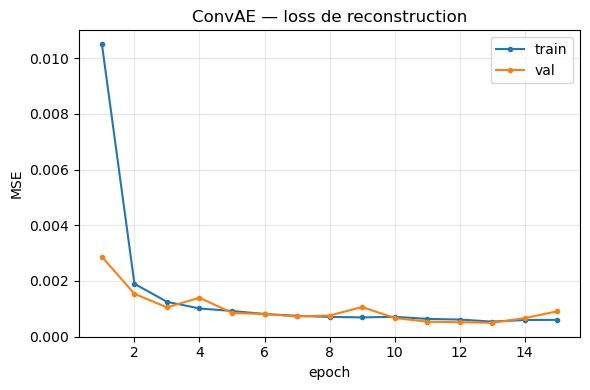

In [14]:
# Courbe d'apprentissage
plt.figure(figsize=(6, 4))
plt.plot(range(1, EPOCHS + 1), hist_conv["train"], "-o", ms=3, label="train")
plt.plot(range(1, EPOCHS + 1), hist_conv["val"],   "-o", ms=3, label="val")
plt.xlabel("epoch"); plt.ylabel("MSE"); plt.title("ConvAE — loss de reconstruction")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

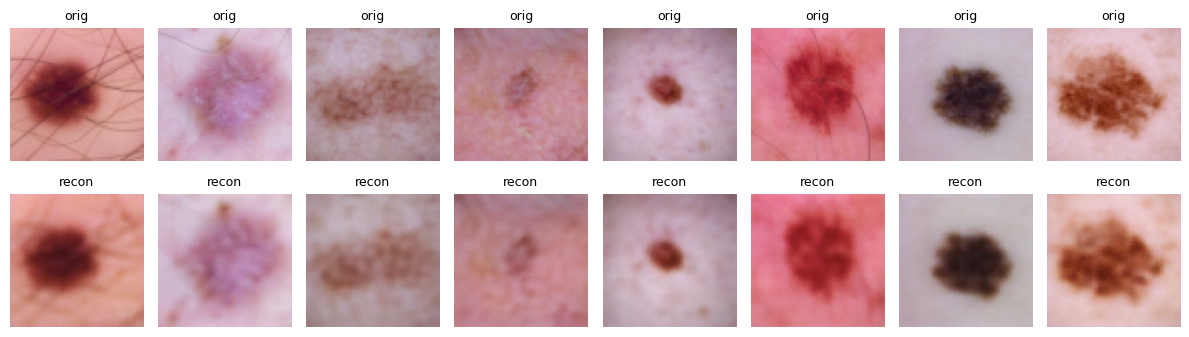

In [15]:
# Originaux (haut) vs reconstructions (bas) sur le test
@torch.no_grad()
def reconstruct(model, x, noise_std=0.0):
    model.eval()
    inp = x if noise_std == 0 else (x + noise_std * torch.randn_like(x)).clamp(0, 1)
    return inp.cpu(), model(inp.to(device)).cpu()

x_test, _ = next(iter(test_loader))
x_test = x_test[:8]
_, rec = reconstruct(conv_ae, x_test)
show_grid([*x_test, *rec], nrow=8,
          titles=["orig"]*8 + ["recon"]*8, figsize=(12, 3.6))

## Partie VI — Denoising Autoencoder (débruitage)

On corrompt l'entrée par un bruit gaussien $\sigma=0.3$ et on entraîne le ConvAE à reconstruire l'image **propre**. C'est le cœur du TP : un débruiteur appris, transposable à l'imagerie médicale (IRM/CT).


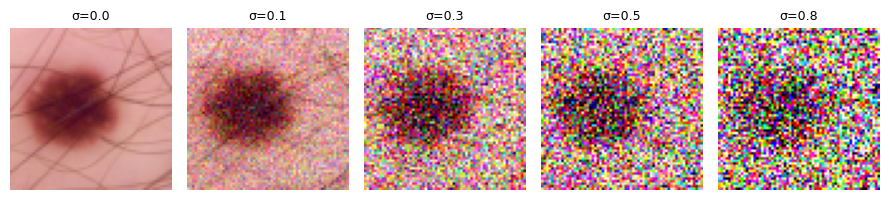

In [16]:
# Effet visuel du bruit gaussien à différents niveaux
levels = [0.0, 0.1, 0.3, 0.5, 0.8]
sample = x_test[0]
noisy_samples = [(sample + s * torch.randn_like(sample)).clamp(0, 1) for s in levels]
show_grid(noisy_samples, nrow=len(levels),
          titles=[f"σ={s}" for s in levels], figsize=(9, 2.2))

In [17]:
NOISE_STD = 0.3
EPOCHS_DAE = 18
torch.manual_seed(SEED)
dae = ConvAE().to(device)                     # même architecture, entrée bruitée
hist_dae = fit(dae, EPOCHS_DAE, lr=1e-3, noise_std=NOISE_STD, tag="DAE")

[DAE] epoch  1/18  train MSE 0.01137  val MSE 0.00361  (13.6s)
[DAE] epoch  2/18  train MSE 0.00248  val MSE 0.00262  (13.5s)
[DAE] epoch  3/18  train MSE 0.00213  val MSE 0.00256  (13.6s)
[DAE] epoch  4/18  train MSE 0.00190  val MSE 0.00204  (13.6s)
[DAE] epoch  5/18  train MSE 0.00169  val MSE 0.00155  (13.6s)
[DAE] epoch  6/18  train MSE 0.00156  val MSE 0.00176  (13.6s)
[DAE] epoch  7/18  train MSE 0.00151  val MSE 0.00150  (13.6s)
[DAE] epoch  8/18  train MSE 0.00144  val MSE 0.00144  (13.6s)
[DAE] epoch  9/18  train MSE 0.00147  val MSE 0.00177  (13.6s)
[DAE] epoch 10/18  train MSE 0.00143  val MSE 0.00158  (13.7s)
[DAE] epoch 11/18  train MSE 0.00143  val MSE 0.00145  (13.6s)
[DAE] epoch 12/18  train MSE 0.00143  val MSE 0.00131  (13.7s)
[DAE] epoch 13/18  train MSE 0.00139  val MSE 0.00134  (13.6s)
[DAE] epoch 14/18  train MSE 0.00134  val MSE 0.00129  (13.7s)
[DAE] epoch 15/18  train MSE 0.00134  val MSE 0.00142  (13.7s)
[DAE] epoch 16/18  train MSE 0.00139  val MSE 0.00125  

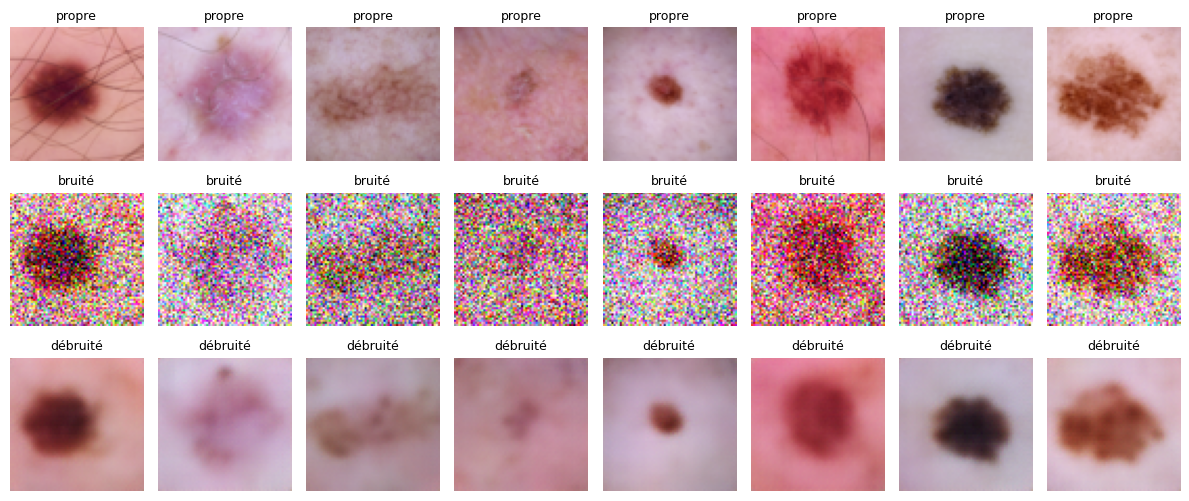

In [18]:
# Débruitage : propre (haut) -> bruité (milieu) -> débruité (bas)
torch.manual_seed(SEED)
noisy_in, denoised = reconstruct(dae, x_test, noise_std=NOISE_STD)
show_grid([*x_test, *noisy_in, *denoised], nrow=8,
          titles=["propre"]*8 + ["bruité"]*8 + ["débruité"]*8, figsize=(12, 5.2))

## Partie VII — Skip connections (U-Net) & gain en PSNR

Le ConvAE produit un débruitage parfois flou : le bottleneck a perdu les hautes fréquences. On ajoute des **skip connections** entre étages symétriques (concaténation sur les canaux) — un mini **U-Net**. On compare ensuite les deux débruiteurs au **PSNR** (Peak Signal-to-Noise Ratio, plus haut = meilleur) :
$$
\text{PSNR} = 10\,\log_{10}\!\frac{\text{MAX}^2}{\text{MSE}}, \qquad \text{MAX}=1 .
$$


In [19]:
class UNetAE(nn.Module):
    '''Mini U-Net : encodeur 3 étages, décodeur avec concaténation des features encodeur.'''
    def __init__(self, base=32):
        super().__init__()
        self.e1 = enc_block(3,      base)      # 64 -> 32
        self.e2 = enc_block(base,   base*2)    # 32 -> 16
        self.e3 = enc_block(base*2, base*4)    # 16 -> 8

        # décodeur : l'entrée de chaque bloc est concaténée avec la feature encodeur de même résolution
        self.d3 = dec_block(base*4,        base*2)            # 8  -> 16
        self.d2 = dec_block(base*2 + base*2, base)            # (16) concat e2 -> 32
        self.d1 = dec_block(base   + base,   3, last=True)    # (32) concat e1 -> 64

    def encode(self, x):
        return self.e3(self.e2(self.e1(x)))

    def forward(self, x):
        s1 = self.e1(x)     # (base,   32, 32)
        s2 = self.e2(s1)    # (base*2, 16, 16)
        z  = self.e3(s2)    # (base*4,  8,  8)
        d  = self.d3(z)                                   # -> 16, base*2
        d  = self.d2(torch.cat([d, s2], dim=1))           # concat skip e2 -> 32
        d  = self.d1(torch.cat([d, s1], dim=1))           # concat skip e1 -> 64
        return d

unet = UNetAE().to(device)
with torch.no_grad():
    out = unet(x_batch.to(device))
print(f"UNetAE — paramètres : {count_params(unet):,}")
print(f"Sortie : {tuple(out.shape)}  (attendu {tuple(x_batch.shape)})")

UNetAE — paramètres : 365,699
Sortie : (128, 3, 64, 64)  (attendu (128, 3, 64, 64))


In [20]:
torch.manual_seed(SEED)
hist_unet = fit(unet, EPOCHS_DAE, lr=1e-3, noise_std=NOISE_STD, tag="U-Net DAE")

[U-Net DAE] epoch  1/18  train MSE 0.01492  val MSE 0.00798  (14.2s)
[U-Net DAE] epoch  2/18  train MSE 0.00440  val MSE 0.00401  (14.3s)
[U-Net DAE] epoch  3/18  train MSE 0.00295  val MSE 0.00278  (14.3s)
[U-Net DAE] epoch  4/18  train MSE 0.00235  val MSE 0.00229  (14.3s)
[U-Net DAE] epoch  5/18  train MSE 0.00206  val MSE 0.00216  (14.3s)
[U-Net DAE] epoch  6/18  train MSE 0.00185  val MSE 0.00172  (14.2s)
[U-Net DAE] epoch  7/18  train MSE 0.00172  val MSE 0.00162  (14.1s)
[U-Net DAE] epoch  8/18  train MSE 0.00160  val MSE 0.00157  (14.1s)
[U-Net DAE] epoch  9/18  train MSE 0.00158  val MSE 0.00155  (14.2s)
[U-Net DAE] epoch 10/18  train MSE 0.00158  val MSE 0.00151  (14.1s)
[U-Net DAE] epoch 11/18  train MSE 0.00150  val MSE 0.00147  (14.2s)
[U-Net DAE] epoch 12/18  train MSE 0.00151  val MSE 0.00140  (14.1s)
[U-Net DAE] epoch 13/18  train MSE 0.00145  val MSE 0.00138  (14.2s)
[U-Net DAE] epoch 14/18  train MSE 0.00144  val MSE 0.00136  (14.1s)
[U-Net DAE] epoch 15/18  train MSE

PSNR moyen (test, σ=0.3) :
  bruité (référence) : 11.81 dB
  ConvAE débruiteur  : 28.95 dB   (+17.14 dB)
  U-Net débruiteur   : 28.85 dB   (+17.03 dB)


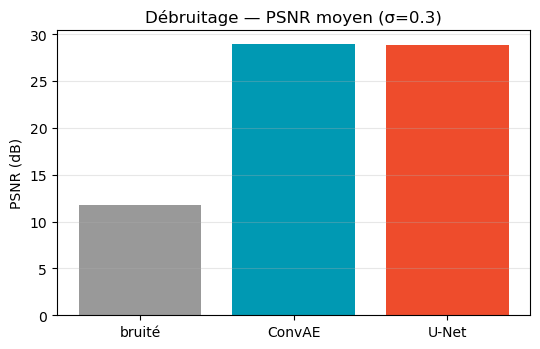

In [21]:
# Comparaison PSNR sur tout le test (à bruit fixé)
def psnr(mse, max_val=1.0):
    mse = max(mse, 1e-12)
    return 10.0 * np.log10(max_val ** 2 / mse)

@torch.no_grad()
def mean_psnr(model, loader, noise_std):
    model.eval()
    tot, n = 0.0, 0
    g = torch.Generator(device=device).manual_seed(SEED)   # bruit reproductible, identique entre modèles
    for x, _ in loader:
        x = x.to(device)
        noisy = (x + noise_std * torch.randn(x.shape, generator=g, device=device)).clamp(0, 1)
        out = model(noisy)
        mse = F.mse_loss(out, x, reduction="none").flatten(1).mean(1)   # MSE par image
        tot += sum(psnr(m.item()) for m in mse); n += x.size(0)
    return tot / n

# référence : PSNR de l'image bruitée non traitée
@torch.no_grad()
def noisy_psnr(loader, noise_std):
    tot, n = 0.0, 0
    g = torch.Generator(device=device).manual_seed(SEED)
    for x, _ in loader:
        x = x.to(device)
        noisy = (x + noise_std * torch.randn(x.shape, generator=g, device=device)).clamp(0, 1)
        mse = F.mse_loss(noisy, x, reduction="none").flatten(1).mean(1)
        tot += sum(psnr(m.item()) for m in mse); n += x.size(0)
    return tot / n

p_noisy = noisy_psnr(test_loader, NOISE_STD)
p_dae   = mean_psnr(dae,  test_loader, NOISE_STD)
p_unet  = mean_psnr(unet, test_loader, NOISE_STD)
print(f"PSNR moyen (test, σ={NOISE_STD}) :")
print(f"  bruité (référence) : {p_noisy:5.2f} dB")
print(f"  ConvAE débruiteur  : {p_dae:5.2f} dB   (+{p_dae - p_noisy:.2f} dB)")
print(f"  U-Net débruiteur   : {p_unet:5.2f} dB   (+{p_unet - p_noisy:.2f} dB)")

plt.figure(figsize=(5.5, 3.6))
plt.bar(["bruité", "ConvAE", "U-Net"], [p_noisy, p_dae, p_unet],
        color=["#999", "#0099b3", "#ee4c2c"])
plt.ylabel("PSNR (dB)"); plt.title(f"Débruitage — PSNR moyen (σ={NOISE_STD})")
plt.grid(axis="y", alpha=.3); plt.tight_layout(); plt.show()

## Partie VIII — Exploration de l'espace latent (UMAP)

On extrait le code latent du **ConvAE** (Partie V) pour tout le test, on l'aplatit, puis on le projette en 2D. Si `umap-learn` est absent, on bascule sur une **PCA**. On **colore par classe** (sans que l'AE les ait jamais vues) pour juger si la variété latente s'organise par similarité visuelle.


Latents extraits : (2000, 8192)  (dim aplatie = 8192)


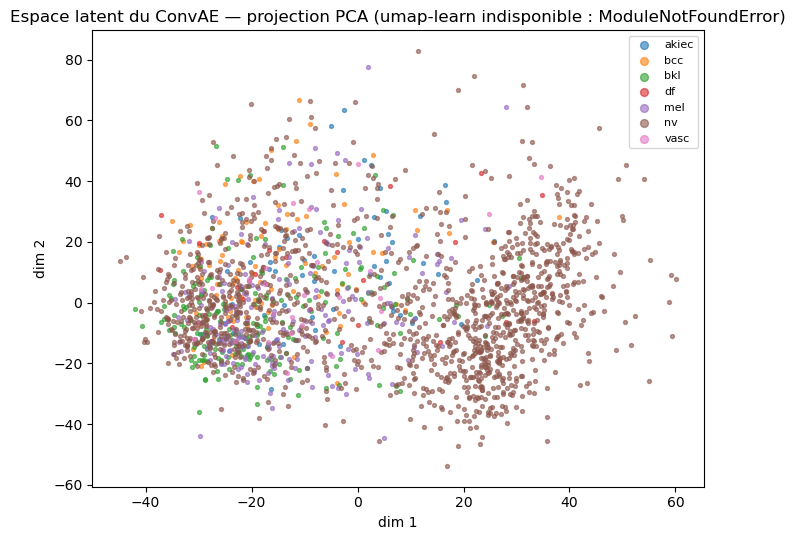

In [22]:
@torch.no_grad()
def extract_latents(model, loader, max_n=2000):
    model.eval()
    Z, Y = [], []
    for x, y in loader:
        z = model.encode(x.to(device)).flatten(1)     # (N, d)
        Z.append(z.cpu().numpy()); Y.append(np.asarray(y))
        if sum(len(a) for a in Z) >= max_n:
            break
    return np.concatenate(Z)[:max_n], np.concatenate(Y)[:max_n]

Z, Y = extract_latents(conv_ae, test_loader, max_n=2000)
print(f"Latents extraits : {Z.shape}  (dim aplatie = {Z.shape[1]})")

try:
    import umap
    emb = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1,
                    random_state=SEED).fit_transform(Z)
    method = "UMAP"
except Exception as e:
    from sklearn.decomposition import PCA
    emb = PCA(n_components=2, random_state=SEED).fit_transform(Z)
    method = f"PCA (umap-learn indisponible : {type(e).__name__})"

plt.figure(figsize=(7, 5.5))
for k in range(NUM_CLASSES):
    m = Y == k
    plt.scatter(emb[m, 0], emb[m, 1], s=8, alpha=.6, label=CLASSES_SHORT[k])
plt.title(f"Espace latent du ConvAE — projection {method}")
plt.xlabel("dim 1"); plt.ylabel("dim 2")
plt.legend(markerscale=2, fontsize=8, loc="best")
plt.tight_layout(); plt.show()

## Partie IX — Détection d'anomalies non supervisée

Protocole : on entraîne un AE **uniquement sur la classe majoritaire** `nv` (le « normal »). À l'inférence, on calcule le **score de reconstruction** $s(\mathbf{x}) = \lVert \mathbf{x}-\hat{\mathbf{x}}\rVert_2^2$ sur le test. Les images d'**autres classes** (les « anomalies ») devraient être moins bien reconstruites $\Rightarrow$ score plus élevé. On fixe le seuil $\tau$ au **quantile 95 %** des scores `nv` de validation et on mesure la séparation (ROC AUC).


In [23]:
NV = CLASSES_SHORT.index("nv")          # classe « normale »

def class_subset(dataset, keep_label):
    idx = [i for i in range(len(dataset)) if dataset[i][1] == keep_label]
    return Subset(dataset, idx)

nv_train = class_subset(train_set, NV)
nv_val   = class_subset(val_set,   NV)
print(f"Sous-ensemble 'normal' (nv) : train={len(nv_train)}  val={len(nv_val)}")

nv_train_loader = DataLoader(nv_train, batch_size=BATCH, shuffle=True,  num_workers=0, drop_last=True)
nv_val_loader   = DataLoader(nv_val,   batch_size=BATCH, shuffle=False, num_workers=0)

# AE entraîné UNIQUEMENT sur le normal
torch.manual_seed(SEED)
ae_anom = ConvAE().to(device)
crit = nn.MSELoss(); opt = torch.optim.Adam(ae_anom.parameters(), lr=1e-3)
for ep in range(1, 13):
    tr = train_recon_epoch(ae_anom, nv_train_loader, crit, opt, device)
    print(f"[anomalie] epoch {ep:2d}/12  train MSE {tr:.5f}")

Sous-ensemble 'normal' (nv) : train=4693  val=671
[anomalie] epoch  1/12  train MSE 0.01473
[anomalie] epoch  2/12  train MSE 0.00231
[anomalie] epoch  3/12  train MSE 0.00153
[anomalie] epoch  4/12  train MSE 0.00124
[anomalie] epoch  5/12  train MSE 0.00100
[anomalie] epoch  6/12  train MSE 0.00083
[anomalie] epoch  7/12  train MSE 0.00081
[anomalie] epoch  8/12  train MSE 0.00076
[anomalie] epoch  9/12  train MSE 0.00069
[anomalie] epoch 10/12  train MSE 0.00067
[anomalie] epoch 11/12  train MSE 0.00067
[anomalie] epoch 12/12  train MSE 0.00062


In [24]:
@torch.no_grad()
def recon_scores(model, loader):
    '''Score d'anomalie = MSE de reconstruction par image, + label.'''
    model.eval()
    scores, labels = [], []
    for x, y in loader:
        x = x.to(device)
        out = model(x)
        s = F.mse_loss(out, x, reduction="none").flatten(1).mean(1)
        scores.append(s.cpu().numpy()); labels.append(np.asarray(y))
    return np.concatenate(scores), np.concatenate(labels)

# Seuil : quantile 95% des scores normaux (validation nv)
val_scores, _ = recon_scores(ae_anom, nv_val_loader)
tau = np.quantile(val_scores, 0.95)

test_scores, test_labels = recon_scores(ae_anom, test_loader)
is_anom = (test_labels != NV).astype(int)          # 1 = anomalie (autre que nv)

from sklearn.metrics import roc_auc_score, roc_curve
auc = roc_auc_score(is_anom, test_scores)
pred_anom = (test_scores > tau).astype(int)
recall   = (pred_anom[is_anom == 1] == 1).mean()
fpr_norm = (pred_anom[is_anom == 0] == 1).mean()
print(f"Seuil τ (quantile 95% normal) : {tau:.5f}")
print(f"ROC AUC (anomalie vs normal)  : {auc:.3f}")
print(f"Au seuil τ — rappel anomalies : {recall:.1%}  |  faux positifs (normal) : {fpr_norm:.1%}")

Seuil τ (quantile 95% normal) : 0.00141
ROC AUC (anomalie vs normal)  : 0.632
Au seuil τ — rappel anomalies : 15.8%  |  faux positifs (normal) : 5.6%


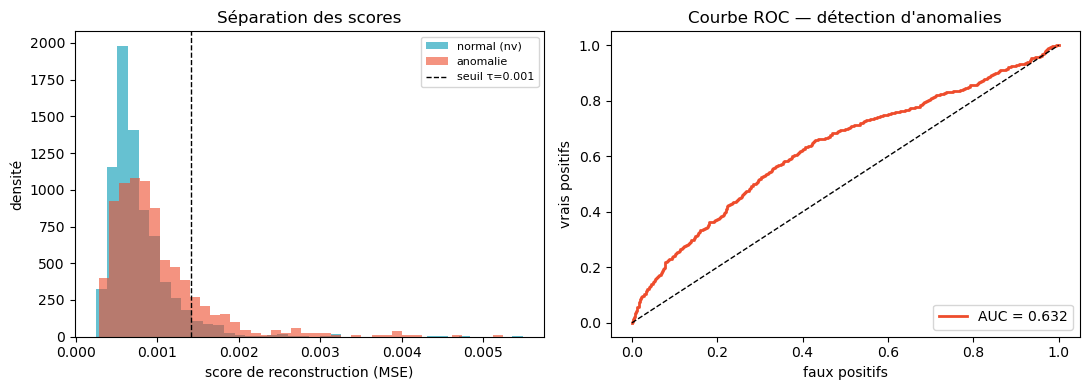

In [25]:
# Distribution des scores + courbe ROC
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].hist(test_scores[is_anom == 0], bins=40, alpha=.6, label="normal (nv)",  color="#0099b3", density=True)
ax[0].hist(test_scores[is_anom == 1], bins=40, alpha=.6, label="anomalie",      color="#ee4c2c", density=True)
ax[0].axvline(tau, color="k", ls="--", lw=1, label=f"seuil τ={tau:.3f}")
ax[0].set_xlabel("score de reconstruction (MSE)"); ax[0].set_ylabel("densité")
ax[0].set_title("Séparation des scores"); ax[0].legend(fontsize=8)

fpr, tpr, _ = roc_curve(is_anom, test_scores)
ax[1].plot(fpr, tpr, color="#ee4c2c", lw=2, label=f"AUC = {auc:.3f}")
ax[1].plot([0, 1], [0, 1], "k--", lw=1)
ax[1].set_xlabel("faux positifs"); ax[1].set_ylabel("vrais positifs")
ax[1].set_title("Courbe ROC — détection d'anomalies"); ax[1].legend(loc="lower right")
plt.tight_layout(); plt.show()

## Partie X — Sauvegarde des modèles

Conformément aux conventions du dépôt, on sauvegarde dans `./checkpoints/` avec le nommage `<arch>_<dataset>_best.pt`.


In [26]:
def save_ckpt(model, name, extra=None):
    path = CKPT_DIR / name
    payload = {"state_dict": model.state_dict(), "img_size": IMG_SIZE, "arch": type(model).__name__}
    if extra:
        payload.update(extra)
    torch.save(payload, path)
    print(f"✓ {path}  ({path.stat().st_size/1e6:.1f} Mo)")

save_ckpt(conv_ae, "convae_dermamnist_best.pt",
          extra={"val_mse": hist_conv["val"][-1]})
save_ckpt(dae,     "dae_dermamnist_best.pt",
          extra={"noise_std": NOISE_STD, "psnr": float(p_dae)})
save_ckpt(unet,    "unet_dae_dermamnist_best.pt",
          extra={"noise_std": NOISE_STD, "psnr": float(p_unet)})
save_ckpt(ae_anom, "convae_anomaly_nv_best.pt",
          extra={"tau": float(tau), "auc": float(auc)})

✓ checkpoints/convae_dermamnist_best.pt  (1.3 Mo)
✓ checkpoints/dae_dermamnist_best.pt  (1.3 Mo)
✓ checkpoints/unet_dae_dermamnist_best.pt  (1.5 Mo)
✓ checkpoints/convae_anomaly_nv_best.pt  (1.3 Mo)


## Partie XI — Exercices d'application

### Exercice 1 — Compromis du bottleneck
Faites varier la dimension latente du `ConvAE` (réduisez `base`, ou ajoutez une `Conv2d` finale 1×1 ramenant à 8, 32, 128 canaux). Tracez la **MSE de validation** en fonction de la taille du code. Où se situe le compromis compression / fidélité ?

### Exercice 2 — `ConvTranspose2d` vs `Upsample + Conv2d`
Réécrivez `dec_block` avec `nn.Upsample(scale_factor=2, mode="nearest") + nn.Conv2d(in_c, out_c, 3, padding=1)`. Comparez visuellement les reconstructions : observez-vous des **artefacts en damier** avec l'une des deux approches ? Que se passe-t-il si vous repassez `ConvTranspose2d` à `kernel_size=3, stride=2` ?

### Exercice 3 — Robustesse au niveau de bruit
Entraînez le DAE à $\sigma=0.3$ puis évaluez son **PSNR** à $\sigma \in \{0.1, 0.3, 0.5, 0.8\}$. Le débruiteur généralise-t-il hors de son niveau d'entraînement ? Comparez à un DAE entraîné avec un $\sigma$ **tiré aléatoirement** par batch.

### Exercice 4 — BCE vs MSE
Remplacez `nn.MSELoss()` par `nn.BCELoss()` (la sortie est déjà sigmoïdée). Comparez la netteté des contours sur les reconstructions. Pourquoi la BCE tend-elle à mieux restituer les bords ?

### Exercice 5 — Détection d'anomalies par classe
Reprenez la Partie IX mais entraînez l'AE sur **chaque** classe « normale » tour à tour. Quelles classes sont les plus faciles à isoler comme anomalies (AUC élevé) ? Reliez le résultat au **déséquilibre** du dataset et à la diversité intra-classe.

### Exercice 6 — Vers le VAE
L'AE déterministe ne sait pas **générer** : échantillonnez $\mathbf{z}\sim\mathcal{N}(\mathbf{0},\mathbf{I})$ de la dimension du bottleneck, passez-le au décodeur du `ConvAE`. Les images obtenues sont-elles réalistes ? Justifiez par l'absence de structure probabiliste du latent — c'est exactement le problème que résout le **VAE** (TP 08).

---

## Synthèse — API PyTorch des Autoencoders

| Concept | API PyTorch |
|---------|-------------|
| Encodeur convolutif (downsampling) | `nn.Conv2d(in_c, out_c, k, stride=2, padding)` |
| Décodeur — conv transposée | `nn.ConvTranspose2d(in_c, out_c, k=4, stride=2, padding=1)` |
| Décodeur — alternative sans damier | `nn.Upsample(scale_factor=2)` + `nn.Conv2d(..., stride=1)` |
| Sortie pixels dans [0,1] | `nn.Sigmoid()` en dernière couche |
| Loss de reconstruction | `nn.MSELoss()`, `nn.BCELoss()` |
| Bruit (Denoising AE) | `(x + sigma * torch.randn_like(x)).clamp(0, 1)` |
| Skip connections (U-Net) | `torch.cat([dec, enc], dim=1)` |
| Normalisation interne | `nn.BatchNorm2d`, `nn.GroupNorm` |
| Extraction du latent | `model.encode(x)` (sous-réseau encodeur) |
| Projection / clustering latent | `umap-learn`, `sklearn.decomposition.PCA`, `TSNE` |
| Score d'anomalie | `F.mse_loss(out, x, reduction="none").flatten(1).mean(1)` |

---

**Prochain TP** (Module 3) : *VAE — Variational Autoencoder* — latent probabiliste, *reparametrization trick*, KL / ELBO, $\beta$-VAE et génération conditionnelle.
